In [8]:
from lens_mass import *
from lens_light import *
from source_light import *
from gw_pop import *
from bbh_pos import *
from likelihood import *
from astropy.cosmology import Planck18 as cosmo

Assuming imaging by euclid


In [24]:
#Sample source galaxy params 

#0 : m_VIS_Euclid (Magnitude in Euclid VIS band)
#1: log10_mStar (Stellar mass in log10 solar mass)
#2 : Re_maj (Sersic effective radius in kpc)
#3 : z (source galaxy redshift)
#4 : q (axis ratio)
#5 : n_sersic (Sersic index)
#6 : log_p_gal (Log probability of the sampled galaxy under the trained MAF)

source_prms = sample_source_galaxy_pars()
zs = source_prms[0][3]
source_q = source_prms[0][4]
source_theta_ell = np.random.uniform(0.0, np.pi)


e1_src, e2_src = param_util.phi_q2_ellipticity(
    source_theta_ell,
    source_q
)
kwargs_source = {
    "source_re": float(source_prms[0][2]),
    "source_nsersic": float(source_prms[0][5]),
    "e1_src": e1_src,
    "e2_src": e2_src
}

In [25]:
kwargs_source

{'source_re': 0.07698080688714981,
 'source_nsersic': 3.537982940673828,
 'e1_src': 0.4014560710686831,
 'e2_src': -0.0065900457885102355}

In [26]:
#Sample lens galaxy params
sigma, zl = sample_sigmaz_ler()
ell_light, theta_light, ell_mass, theta_mass = sample_ellipticity_theta(sigma=sigma,size=1)
gamma_slope = sample_slope_gamma()
gamma_shear, phi_shear = sample_shear()
lens_x , lens_y = sample_lens_position()
Mr, re, k_corr =  sample_FP(sigma, zl, ell_light)
theta_ein = einstein_radius(float(sigma), float(zl) , float(zs))


e1,e2 = param_util.phi_q2_ellipticity(phi=theta_mass, q=1 - ell_mass)
e1_src,e2_src = param_util.phi_q2_ellipticity(phi=source_theta_ell, q=source_q)
gamma1, gamma2 = param_util.shear_polar2cartesian(phi=phi_shear, gamma=gamma_shear)
lens_nsersic = 4.
kwargs_lens = [{'theta_E': float(theta_ein), 'gamma': float(gamma_slope), 'e1': float(e1), 'e2': float(e2), 'center_x': float(lens_x), 'center_y':float(lens_y)},
                       {'gamma1': float(gamma1), 'gamma2': float(gamma2)}]

 



Initializing LensGalaxyParameterDistribution class...


Initializing OpticalDepth class

comoving_distance interpolator will be loaded from ./interpolator_json/comoving_distance/comoving_distance_0.json
angular_diameter_distance interpolator will be loaded from ./interpolator_json/angular_diameter_distance/angular_diameter_distance_0.json
angular_diameter_distance interpolator will be loaded from ./interpolator_json/angular_diameter_distance/angular_diameter_distance_0.json
differential_comoving_volume interpolator will be loaded from ./interpolator_json/differential_comoving_volume/differential_comoving_volume_0.json
using ler available velocity dispersion function : velocity_dispersion_ewoud
velocity_dispersion_ewoud interpolator will be loaded from ./interpolator_json/velocity_dispersion/velocity_dispersion_ewoud_0.json
using ler available axis_ratio function : axis_ratio_rayleigh
axis_ratio_rayleigh interpolator will be loaded from ./interpolator_json/axis_ratio/axis_ratio_rayleig

In [49]:
# Sample GW params
gw_prms = sample_gw_params(1)
zgw = zs
gw_prms['mass_1'] = gw_prms['mass_1_source'] * (1+zgw)
gw_prms['mass_2'] = gw_prms['mass_2_source'] * (1+zgw)
gw_prms['luminosity_distance'] = cosmo.luminosity_distance([zgw]).value


Initializing CBCSourceRedshiftDistribution class...

luminosity_distance interpolator will be loaded from ./interpolator_json/luminosity_distance/luminosity_distance_1.json
differential_comoving_volume interpolator will be loaded from ./interpolator_json/differential_comoving_volume/differential_comoving_volume_1.json
using ler available merger rate density model: merger_rate_density_madau_dickinson_belczynski_ng
merger_rate_density_madau_dickinson_belczynski_ng interpolator will be loaded from ./interpolator_json/merger_rate_density/merger_rate_density_madau_dickinson_belczynski_ng_2.json
merger_rate_density_detector_frame interpolator will be loaded from ./interpolator_json/merger_rate_density/merger_rate_density_detector_frame_3.json
source_redshift interpolator will be loaded from ./interpolator_json/source_redshift/source_redshift_1.json

Initializing CBCSourceParameterDistribution class...

using ler available zs function : source_redshift
using ler available source_frame_masses

In [28]:
#Sample BBH and source galaxy positions
x_gw, y_gw, area, source_x , source_y =  sample_gwpos_then_sourcepos(kwargs_lens=kwargs_lens, kwargs_source=kwargs_source, num_detected_gws=4)

In [29]:
mag_lens = Mr + 5 * np.log10((cosmo.luminosity_distance(zl)/(10 * u.pc)).to_value(1)) + k_corr

In [30]:
#Probabilities
pcross = float(lik_cross_sec(area))
psrc = float(lik_sourcepop(source_prms))

In [31]:
PdetEM = lik_img(float(mag_lens), float(re), (float(lens_x), float(lens_y)),
    float(source_prms[0][0]), kwargs_source['source_re'], 1-float(source_q), float(source_theta_ell), (source_x, source_y),
    kwargs_lens,
    lens_model_class=None,
    lens_nsersic=4., source_nsersic=kwargs_source['source_nsersic'],
    elliptic_lensgal=True, lens_light_theta_ell_ell=None,
    require_source_snr=True, verbose=True)

too smalll einstein radius
Unobservable lens system, mlens=26.12621569406654, msource=38.987125396728516


In [32]:
lens_params = {'zl':zl, 'zs':np.array([zs]),'theta_E':np.array([theta_ein]), 'q':1 - ell_mass,'phi':theta_mass, 'gamma': gamma_slope,'gamma1': gamma1 , 'gamma2':gamma2}

In [33]:
Pdet_GW = simulate_lensed_gw_detection(
    gw_prms,
    lens_params,
    num_required_images=2,
    num_detected_gws=2,
    snr_threshold=7.0)
Pdet_GW

solving lens equations...


100%|█████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 14.80it/s]


Initializing GWSNR class...

psds not given. Choosing bilby's default psds


Intel processor has trouble allocating memory when the data is huge. So, by default for IMRPhenomXPHM, duration_max = 64.0. Otherwise, set to some max value like duration_max = 600.0 (10 mins)
Interpolator will be loaded for L1 detector from ./interpolator_json/L1/partialSNR_dict_1.json
Interpolator will be loaded for H1 detector from ./interpolator_json/H1/partialSNR_dict_1.json
Interpolator will be loaded for V1 detector from ./interpolator_json/V1/partialSNR_dict_1.json

Chosen GWSNR initialization parameters:

npool:  4
snr type:  interpolation_aligned_spins
waveform approximant:  IMRPhenomXPHM
sampling frequency:  2048.0
minimum frequency (fmin):  20.0
reference frequency (f_ref):  20.0
mtot=mass1+mass2
min(mtot):  9.96
max(mtot) (with the given fmin=20.0): 235.0
detectors:  ['L1', 'H1', 'V1']
psds:  [[array([  10.21659,   10.23975,   10.26296, ..., 4972.81   ,
       4984.081  , 4995.378  ], shape=(2736,)), array([4.43925574e-41, 4.22777986e-41, 4.02102594e-41, ...,
       6.5115

(False,
 {'optimal_snr_net': array([2.50205732, 3.59826052, 2.15009321, 2.40342797]),
  'optimal_snr_H1': array([1.33866926, 1.8752069 , 1.32212115, 1.37541612]),
  'optimal_snr_L1': array([1.88321849, 2.55850782, 1.64910415, 1.76243449]),
  'optimal_snr_V1': array([0.96007478, 1.69856282, 0.39414714, 0.88233847])},
 {'mass_1_source': array([7.32864215]),
  'mass_2_source': array([6.91017184]),
  'a_1': array([0.16732589]),
  'a_2': array([0.28080806]),
  'tilt_1': array([1.66593604]),
  'tilt_2': array([1.42313104]),
  'phi_12': array([4.93851563]),
  'phi_jl': array([5.22615152]),
  'theta_jn': array([2.90537333]),
  'ra': array([5.71757122]),
  'dec': array([-0.49322928]),
  'psi': array([1.6328607]),
  'geocent_time': array([1.24475129e+09]),
  'phase': array([5.04434803]),
  'mass_1': array([59.89565286]),
  'mass_2': array([56.4755715]),
  'luminosity_distance': array([72501.74738518]),
  'zl': array([1.58096993]),
  'zs': array([7.17281723]),
  'theta_E': array([0.05886615]),
  

In [34]:
def logL(pcross, psrc, PdetEM, PdetGW):
    if PdetEM[0] == True and PdetGW[0] == True:
        return True
    else:
        return False

In [35]:
logL(pcross, psrc, PdetEM, Pdet_GW)

False

In [6]:
import pandas as pd
catalog = pd.read_csv("not_detected_catalog_2.csv")

gw_catalog = catalog[catalog["PdetGW_flag"] == True].reset_index(drop=True)
gw_catalog['mass_1_source'] = gw_catalog['mass_1']/ (1 + gw_catalog['z_source'])
gw_catalog['mass_2_source'] = gw_catalog['mass_2']/ (1 + gw_catalog['z_source'])
print("GW detectable events in catalog:", len(gw_catalog))

GW_KEYS = [
    'mass_1_source',
    'mass_2_source',
    'theta_jn',
    'psi',
    'phase',
    'ra',
    'dec',
    'geocent_time',
    'a_1',
    'a_2',
    'tilt_1',
    'tilt_2',
    'phi_12',
    'phi_jl']

GW detectable events in catalog: 10


In [15]:
gw_catalog[0:1]

,detected,m_VIS_Euclid,log10_mStar,Re_maj,z_source,q_source,n_sersic_source,log_p_gal,source_theta_ell,source_x,...,magnifications,time_delays,image_type,effective_luminosity_distance,effective_geocent_time,effective_phase,effective_ra,effective_dec,mass_1_source,mass_2_source
0,False,29.065844,7.176676,0.196813,1.028486,0.201144,0.84008,-3.002578,0.275199,-0.242953,...,"[[-13.107904820963276, -9.195094442401626]]","[[2385956169270892.0, 0.0]]","[[2.0, 2.0]]","[[1941.84201045211, 2318.4750947412563]]","[[2385957410410112.5, 1241139220.4573667]]","[[3.7465619295652415, 3.7465619295652415]]","[[2.7400164128767663, 2.467413544651205]]","[[1.013773124714489, 0.5339411915571972]]",35.986385,17.609392


In [55]:
import json
detected_rows = []
MAX_ATTEMPTS = 20
for i in range(10):

    print("Simulating event", i)

    gw_row = gw_catalog[1:2]

    gw_prms = {}

    for key in GW_KEYS:
        gw_prms[key] = np.array(gw_row[key])

    attempts = 0
    detected = False

    while not detected and attempts < MAX_ATTEMPTS:

        attempts += 1
        # =========================================
        # SAMPLE SOURCE GALAXY
        # =========================================

        source_prms = sample_source_galaxy_pars()

        zs = source_prms[0][3]
        source_q = source_prms[0][4]

        source_theta_ell = np.random.uniform(0.0, np.pi)

        e1_src, e2_src = param_util.phi_q2_ellipticity(
            source_theta_ell,
            source_q
        )

        kwargs_source = {
            "source_re": float(source_prms[0][2]),
            "source_nsersic": float(source_prms[0][5]),
            "e1_src": e1_src,
            "e2_src": e2_src
        }

        # =========================================
        # SAMPLE LENS
        # =========================================

        sigma, zl = sample_sigmaz_ler()

        ell_light, theta_light, ell_mass, theta_mass = sample_ellipticity_theta(
            sigma=sigma,
            size=1
        )

        gamma_slope = sample_slope_gamma()

        gamma_shear, phi_shear = sample_shear()

        lens_x, lens_y = sample_lens_position()

        Mr, re, k_corr = sample_FP(sigma, zl, ell_light)

        theta_ein = einstein_radius(float(sigma), float(zl), float(zs))

        mag_lens = Mr + 5*np.log10(
            (cosmo.luminosity_distance(zl)/(10*u.pc)).to_value(1)
        ) + k_corr

        e1, e2 = param_util.phi_q2_ellipticity(
            phi=theta_mass,
            q=1 - ell_mass
        )

        gamma1, gamma2 = param_util.shear_polar2cartesian(
            phi=phi_shear,
            gamma=gamma_shear
        )

        kwargs_lens = [
            {
                'theta_E': float(theta_ein),
                'gamma': float(gamma_slope),
                'e1': float(e1),
                'e2': float(e2),
                'center_x': float(lens_x),
                'center_y': float(lens_y)
            },
            {
                'gamma1': float(gamma1),
                'gamma2': float(gamma2)
            }
        ]

        lens_params = {
            'zl': zl,
            'zs': np.array([zs]),
            'theta_E': np.array([theta_ein]),
            'q': 1 - ell_mass,
            'phi': theta_mass,
            'gamma': gamma_slope,
            'gamma1': gamma1,
            'gamma2': gamma2
        }

        # =========================================
        # MATCH GW REDSHIFT TO SOURCE
        # =========================================

        zgw = zs

        gw_prms['mass_1'] = gw_prms['mass_1_source'] * (1 + zgw)
        gw_prms['mass_2'] = gw_prms['mass_2_source'] * (1 + zgw)

        gw_prms['luminosity_distance'] = cosmo.luminosity_distance([zgw]).value

        # =========================================
        # SAMPLE POSITIONS
        # =========================================

        x_gw, y_gw, area, source_x, source_y = sample_gwpos_then_sourcepos(
            kwargs_lens=kwargs_lens,
            kwargs_source=kwargs_source,
            num_detected_gws=2
        )

        # =========================================
        # PROBABILITIES
        # =========================================

        pcross = float(lik_cross_sec(area))

        psrc = float(lik_sourcepop(source_prms))

        PdetEM = lik_img(
            float(mag_lens),
            float(re),
            (float(lens_x), float(lens_y)),
            float(source_prms[0][0]),
            kwargs_source['source_re'],
            1 - float(source_q),
            float(source_theta_ell),
            (source_x, source_y),
            kwargs_lens,
            lens_model_class=None,
            lens_nsersic=4.,
            source_nsersic=kwargs_source['source_nsersic'],
            elliptic_lensgal=True,
            lens_light_theta_ell_ell=None,
            require_source_snr=True,
            verbose=False
        )

        PdetGW = simulate_lensed_gw_detection(
            gw_prms,
            lens_params,
            num_required_images=2,
            num_detected_gws=2,
            snr_threshold=7.0
        )

        detected = PdetEM[0] and PdetGW[0]

    # =========================================
    # IF DETECTION FAILED AFTER MANY ATTEMPTS
    # =========================================

    if not detected:
        print("Reached max attempts, skipping system")
        continue

    print(f"Detected after {attempts} attempts")

    # =========================================
    # STORE ROW
    # =========================================

    row = {}

    row["attempts"] = attempts
    row["weight"] = 1.0 / attempts

    # -----------------------------
    # SOURCE PARAMETERS
    # -----------------------------

    row.update({
        "m_VIS_Euclid": float(source_prms[0][0]),
        "log10_mStar": float(source_prms[0][1]),
        "Re_maj": float(source_prms[0][2]),
        "z_source": float(source_prms[0][3]),
        "q_source": float(source_prms[0][4]),
        "n_sersic_source": float(source_prms[0][5]),
        "log_p_gal": float(source_prms[0][6]),
        "source_theta_ell": float(source_theta_ell),
        "source_x": float(source_x),
        "source_y": float(source_y)
    })

    # -----------------------------
    # LENS PARAMETERS
    # -----------------------------

    row["theta_E"] = float(theta_ein)
    row["zl"] = float(zl)

    # -----------------------------
    # GW PARAMETERS
    # -----------------------------

    GW_KEYS = [
        'mass_1','mass_2','theta_jn','psi','phase','ra','dec',
        'geocent_time','a_1','a_2','tilt_1','tilt_2','phi_12','phi_jl', 'zgw', 'mass_1_source', 'mass_2_source'
    ]

    for key in GW_KEYS:
        row[key] = float(np.atleast_1d(gw_prms[key])[0])

    row["luminosity_distance"] = float(gw_prms['luminosity_distance'])

    # -----------------------------
    # PROBABILITIES
    # -----------------------------

    row["pcross"] = pcross
    row["psrc"] = psrc

    row["PdetEM_flag"] = PdetEM[0]
    row["PdetEM_logL"] = PdetEM[1]
    row["PdetGW_flag"] = PdetGW[0]

    # -----------------------------
    # SAVE SNR
    # -----------------------------

    if PdetGW[1] is not None:

        snr_dict = PdetGW[1]

        row["snr_net"] = json.dumps(snr_dict["optimal_snr_net"].tolist())
        row["snr_H1"] = json.dumps(snr_dict["optimal_snr_H1"].tolist())
        row["snr_L1"] = json.dumps(snr_dict["optimal_snr_L1"].tolist())
        row["snr_V1"] = json.dumps(snr_dict["optimal_snr_V1"].tolist())

    else:

        row["snr_net"] = None
        row["snr_H1"] = None
        row["snr_L1"] = None
        row["snr_V1"] = None

    # -----------------------------
    # SAVE LENSED GW PARAMETERS
    # -----------------------------

    if PdetGW[2] is not None:

        lensed = PdetGW[2]

        keys = [
            "x0_image_positions",
            "x1_image_positions",
            "magnifications",
            "time_delays",
            "image_type",
            "effective_luminosity_distance",
            "effective_geocent_time",
            "effective_phase",
            "effective_ra",
            "effective_dec"
        ]

        for key in keys:
            row[key] = json.dumps(lensed[key].tolist())

    else:

        for key in [
            "x0_image_positions",
            "x1_image_positions",
            "magnifications",
            "time_delays",
            "image_type",
            "effective_luminosity_distance",
            "effective_geocent_time",
            "effective_phase",
            "effective_ra",
            "effective_dec"
        ]:
            row[key] = None


    detected_rows.append(row)


# =========================================
# SAVE CATALOG
# =========================================

detected_df = pd.DataFrame(detected_rows)

detected_df.to_csv("detected_catalog_gw-em.csv", index=False)

print("\nCatalog saved.")





Simulating event 0

Initializing LensGalaxyParameterDistribution class...


Initializing OpticalDepth class

comoving_distance interpolator will be loaded from ./interpolator_json/comoving_distance/comoving_distance_0.json
angular_diameter_distance interpolator will be loaded from ./interpolator_json/angular_diameter_distance/angular_diameter_distance_0.json
angular_diameter_distance interpolator will be loaded from ./interpolator_json/angular_diameter_distance/angular_diameter_distance_0.json
differential_comoving_volume interpolator will be loaded from ./interpolator_json/differential_comoving_volume/differential_comoving_volume_0.json
using ler available velocity dispersion function : velocity_dispersion_ewoud
velocity_dispersion_ewoud interpolator will be loaded from ./interpolator_json/velocity_dispersion/velocity_dispersion_ewoud_0.json
using ler available axis_ratio function : axis_ratio_rayleigh
axis_ratio_rayleigh interpolator will be loaded from ./interpolator_json/axis_ratio

100%|█████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  9.61it/s]



Initializing GWSNR class...

psds not given. Choosing bilby's default psds
Intel processor has trouble allocating memory when the data is huge. So, by default for IMRPhenomXPHM, duration_max = 64.0. Otherwise, set to some max value like duration_max = 600.0 (10 mins)
Interpolator will be loaded for L1 detector from ./interpolator_json/L1/partialSNR_dict_1.json
Interpolator will be loaded for H1 detector from ./interpolator_json/H1/partialSNR_dict_1.json
Interpolator will be loaded for V1 detector from ./interpolator_json/V1/partialSNR_dict_1.json

Chosen GWSNR initialization parameters:

npool:  4
snr type:  interpolation_aligned_spins
waveform approximant:  IMRPhenomXPHM
sampling frequency:  2048.0
minimum frequency (fmin):  20.0
reference frequency (f_ref):  20.0
mtot=mass1+mass2
min(mtot):  9.96
max(mtot) (with the given fmin=20.0): 235.0
detectors:  ['L1', 'H1', 'V1']
psds:  [[array([  10.21659,   10.23975,   10.26296, ..., 4972.81   ,
       4984.081  , 4995.378  ], shape=(2736,)

100%|█████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 12.03it/s]



Initializing GWSNR class...

psds not given. Choosing bilby's default psds
Intel processor has trouble allocating memory when the data is huge. So, by default for IMRPhenomXPHM, duration_max = 64.0. Otherwise, set to some max value like duration_max = 600.0 (10 mins)
Interpolator will be loaded for L1 detector from ./interpolator_json/L1/partialSNR_dict_1.json
Interpolator will be loaded for H1 detector from ./interpolator_json/H1/partialSNR_dict_1.json
Interpolator will be loaded for V1 detector from ./interpolator_json/V1/partialSNR_dict_1.json

Chosen GWSNR initialization parameters:

npool:  4
snr type:  interpolation_aligned_spins
waveform approximant:  IMRPhenomXPHM
sampling frequency:  2048.0
minimum frequency (fmin):  20.0
reference frequency (f_ref):  20.0
mtot=mass1+mass2
min(mtot):  9.96
max(mtot) (with the given fmin=20.0): 235.0
detectors:  ['L1', 'H1', 'V1']
psds:  [[array([  10.21659,   10.23975,   10.26296, ..., 4972.81   ,
       4984.081  , 4995.378  ], shape=(2736,)

...


Initializing GWSNR class...

psds not given. Choosing bilby's default psds
Intel processor has trouble allocating memory when the data is huge. So, by default for IMRPhenomXPHM, duration_max = 64.0. Otherwise, set to some max value like duration_max = 600.0 (10 mins)
Interpolator will be loaded for L1 detector from ./interpolator_json/L1/partialSNR_dict_1.json
Interpolator will be loaded for H1 detector from ./interpolator_json/H1/partialSNR_dict_1.json
Interpolator will be loaded for V1 detector from ./interpolator_json/V1/partialSNR_dict_1.json

Chosen GWSNR initialization parameters:

npool:  4
snr type:  interpolation_aligned_spins
waveform approximant:  IMRPhenomXPHM
sampling frequency:  2048.0
minimum frequency (fmin):  20.0
reference frequency (f_ref):  20.0
mtot=mass1+mass2
min(mtot):  9.96
max(mtot) (with the given fmin=20.0): 235.0
detectors:  ['L1', 'H1', 'V1']
psds:  [[array([  10.21659,   10.23975,   10.26296, ..., 4972.81   ,
       4984.081  , 4995.378  ], shape=(2736,)

100%|█████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 64.30it/s]



Initializing GWSNR class...

psds not given. Choosing bilby's default psds
Intel processor has trouble allocating memory when the data is huge. So, by default for IMRPhenomXPHM, duration_max = 64.0. Otherwise, set to some max value like duration_max = 600.0 (10 mins)
Interpolator will be loaded for L1 detector from ./interpolator_json/L1/partialSNR_dict_1.json
Interpolator will be loaded for H1 detector from ./interpolator_json/H1/partialSNR_dict_1.json
Interpolator will be loaded for V1 detector from ./interpolator_json/V1/partialSNR_dict_1.json

Chosen GWSNR initialization parameters:

npool:  4
snr type:  interpolation_aligned_spins
waveform approximant:  IMRPhenomXPHM
sampling frequency:  2048.0
minimum frequency (fmin):  20.0
reference frequency (f_ref):  20.0
mtot=mass1+mass2
min(mtot):  9.96
max(mtot) (with the given fmin=20.0): 235.0
detectors:  ['L1', 'H1', 'V1']
psds:  [[array([  10.21659,   10.23975,   10.26296, ..., 4972.81   ,
       4984.081  , 4995.378  ], shape=(2736,)

100%|█████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 73.25it/s]



Initializing GWSNR class...

psds not given. Choosing bilby's default psds
Intel processor has trouble allocating memory when the data is huge. So, by default for IMRPhenomXPHM, duration_max = 64.0. Otherwise, set to some max value like duration_max = 600.0 (10 mins)
Interpolator will be loaded for L1 detector from ./interpolator_json/L1/partialSNR_dict_1.json
Interpolator will be loaded for H1 detector from ./interpolator_json/H1/partialSNR_dict_1.json
Interpolator will be loaded for V1 detector from ./interpolator_json/V1/partialSNR_dict_1.json

Chosen GWSNR initialization parameters:

npool:  4
snr type:  interpolation_aligned_spins
waveform approximant:  IMRPhenomXPHM
sampling frequency:  2048.0
minimum frequency (fmin):  20.0
reference frequency (f_ref):  20.0
mtot=mass1+mass2
min(mtot):  9.96
max(mtot) (with the given fmin=20.0): 235.0
detectors:  ['L1', 'H1', 'V1']
psds:  [[array([  10.21659,   10.23975,   10.26296, ..., 4972.81   ,
       4984.081  , 4995.378  ], shape=(2736,)

In [1]:
import pandas as pd
cat = pd.read_csv('detected_catalog_gw-em.csv')


In [6]:
catalog = pd.read_csv("not_detected_catalog_2.csv")

gw_catalog = catalog[catalog["PdetGW_flag"] == True].reset_index(drop=True)

In [9]:
gw_catalog['a_1']

0    0.792877
1    0.555666
2    0.159319
3    0.572576
4    0.641082
5    0.433541
6    0.012571
7    0.661752
8    0.274066
9    0.310949
Name: a_1, dtype: float64

In [6]:
cat.keys()

Index(['attempts', 'weight', 'm_VIS_Euclid', 'log10_mStar', 'Re_maj',
       'z_source', 'q_source', 'n_sersic_source', 'log_p_gal',
       'source_theta_ell', 'source_x', 'source_y', 'theta_E', 'zl', 'mass_1',
       'mass_2', 'theta_jn', 'psi', 'phase', 'ra', 'dec', 'geocent_time',
       'a_1', 'a_2', 'tilt_1', 'tilt_2', 'phi_12', 'phi_jl', 'zgw',
       'mass_1_source', 'mass_2_source', 'luminosity_distance', 'pcross',
       'psrc', 'PdetEM_flag', 'PdetEM_logL', 'PdetGW_flag'],
      dtype='object')

In [18]:
from lenstronomy.LensModel.lens_model import LensModel

lens_model_list = ['EPL', 'SHEAR']
lens_model = LensModel(lens_model_list=lens_model_list)

kwargs_lens = [
    {
        'theta_E': cat['theta_E'][0],
        'gamma': 2.0,
        'e1': 0.05,
        'e2': 0.2,
        'center_x': 0.01,
        'center_y': 0.02
    },
    {
        'gamma1': 0.1,
        'gamma2': 0.1
    }
]

from lenstronomy.LightModel.light_model import LightModel

source_model_list = ['SERSIC_ELLIPSE']
source_model = LightModel(light_model_list=source_model_list)
e1_src, e2_src = param_util.phi_q2_ellipticity(
            cat['source_theta_ell'][0],
            cat['q_source'][0]
        )

ZP = 25.1209 
kwargs_source = [{
    'amp': 10 ** (-(cat['m_VIS_Euclid'][0] - ZP) / 2.5),
    'R_sersic': cat['Re_maj'][0],
    'n_sersic': cat['n_sersic_source'][0],
    'e1': e1_src,
    'e2': e2_src,
    'center_x': cat['source_x'][0],
    'center_y': cat['source_y'][0]
}]

In [19]:
import numpy as np

numPix = 100
deltaPix = 0.05

x = np.linspace(-numPix/2*deltaPix, numPix/2*deltaPix, numPix)
y = np.linspace(-numPix/2*deltaPix, numPix/2*deltaPix, numPix)

xx, yy = np.meshgrid(x, y)
beta_x, beta_y = lens_model.ray_shooting(xx, yy, kwargs_lens)
image = source_model.surface_brightness(beta_x, beta_y, kwargs_source)

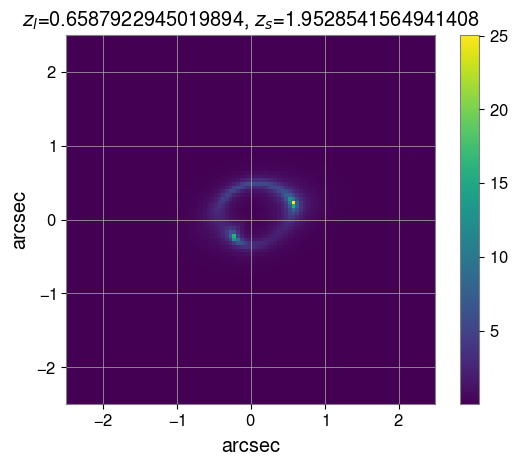

In [20]:
import matplotlib.pyplot as plt

plt.imshow(image, origin='lower', extent=[x.min(), x.max(), y.min(), y.max()])
plt.colorbar()
#plt.scatter(x_images, y_images, marker='*', color='red', s=80)
from lenstronomy.LensModel.lens_model_extensions import LensModelExtensions

lens_ext = LensModelExtensions(lens_model)

ra_crit, dec_crit = lens_ext.critical_curve_tiling(kwargs_lens)

for i in range(len(ra_crit)):
    plt.plot(ra_crit[i], dec_crit[i], color='orange')

beta_crit_x, beta_crit_y = lens_model.ray_shooting(ra_crit, dec_crit, kwargs_lens)

for i in range(len(beta_crit_x)):
    plt.plot(beta_crit_x[i], beta_crit_y[i], color='yellow')

plt.title(f"$z_l$={cat['zl'][0]}, $z_s$={cat['z_source'][0]}")
plt.xlabel("arcsec")
plt.ylabel("arcsec")
plt.show()

In [17]:
ra_crit

array([-0.296875  , -0.30729167, -0.296875  , ...,  0.265625  ,
        0.25520833,  0.359375  ], shape=(288,))